# Recipe Rating Classification with Logistic Regression Champion

This notebook predicts whether a recipe belongs to the lower-rated group.


## 1. Import Libraries


In [37]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 2. Load the Cleaned Data

This notebook uses two cleaned files created by `clean_data.py`.

`recipes_clean.csv` has one row per recipe. `recipes_ingredients_long.csv` has one row per recipe-ingredient.

In [38]:
def find_file(filename):
    possible_paths = [
        filename,
        os.path.join("..", filename),
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
    ]

    for path in possible_paths:
        if os.path.exists(path):
            return path

    raise FileNotFoundError(f"Could not find {filename}. Check that the file is in the project folder or data folder.")


recipes_path = find_file("recipes_clean.csv")
long_path = find_file("recipes_ingredients_long.csv")

recipes = pd.read_csv(recipes_path)
long_df = pd.read_csv(long_path)

print("Loaded:", recipes_path)
print("Loaded:", long_path)
print("recipes_clean shape:", recipes.shape)
print("recipes_ingredients_long shape:", long_df.shape)

recipes.head()

Loaded: recipes_clean.csv
Loaded: recipes_ingredients_long.csv
recipes_clean shape: (14438, 16)
recipes_ingredients_long shape: (139238, 19)


,recipe_id,title,rating_value,rating_value_num,rating_count,rating_count_num,nutrition_calories,nutrition_calories_num,nutrition_carbs,nutrition_carbs_num,nutrition_fat,nutrition_fat_num,nutrition_protein,nutrition_protein_num,url,ingredient_count
0,0,3-Ingredient Air Fryer Everything Bagel Chicke...,4.6,4.6,8.0,8.0,366 kcal,366.0,22 g,22.0,22 g,22.0,21 g,21.0,https://www.allrecipes.com/3-ingredient-air-fr...,3
1,1,4 Ingredient Air Fryer Pepper Poppers,NaN,NaN,0.0,0.0,244 kcal,244.0,6 g,6.0,23 g,23.0,4 g,4.0,https://www.allrecipes.com/4-ingredient-air-fr...,4
2,2,Air Fried Tossed Taquitos,NaN,NaN,0.0,0.0,534 kcal,534.0,57 g,57.0,27 g,27.0,17 g,17.0,https://www.allrecipes.com/air-fried-tossed-ta...,6
3,3,Air Fryer 2-Ingredient Mozzarella Sticks,4.5,4.5,4.0,4.0,395 kcal,395.0,30 g,30.0,23 g,23.0,17 g,17.0,https://www.allrecipes.com/air-fryer-2-ingredi...,6
4,4,Air Fryer Baked Yams,NaN,NaN,0.0,0.0,283 kcal,283.0,62 g,62.0,3 g,3.0,3 g,3.0,https://www.allrecipes.com/air-fryer-baked-yam...,2


## 3. Modeling Settings

The target is binary. A recipe is labeled as lower-rated if its rating is below the selected threshold.

Only recipes with at least 10 ratings are used so that recipes with very few reviews do not create unstable labels.

In [39]:
MIN_RATING_COUNT = 10
selected_threshold = 4.4
TOP_N_INGREDIENTS = 100
RANDOM_STATE = 42
TEST_SIZE = 0.25

print("Minimum rating count:", MIN_RATING_COUNT)
print("Lower-rated threshold:", selected_threshold)
print("Top ingredients used:", TOP_N_INGREDIENTS)

Minimum rating count: 10
Lower-rated threshold: 4.4
Top ingredients used: 100


## 4. Clean Numeric Columns

In [40]:
numeric_cols = [
    "rating_value_num",
    "rating_count_num",
    "nutrition_calories_num",
    "nutrition_carbs_num",
    "nutrition_fat_num",
    "nutrition_protein_num",
    "ingredient_count"
]

for col in numeric_cols:
    if col in recipes.columns:
        recipes[col] = pd.to_numeric(recipes[col], errors="coerce")
    else:
        print("Missing column:", col)

recipes[numeric_cols].describe()

,rating_value_num,rating_count_num,nutrition_calories_num,nutrition_carbs_num,nutrition_fat_num,nutrition_protein_num,ingredient_count
count,13516.000000,14396.000000,14200.000000,14186.000000,14048.000000,14155.000000,14438.000000
mean,4.529609,210.093081,349.117042,33.115113,18.066344,14.663017,9.643856
std,0.411447,751.828205,254.741234,28.354681,16.784422,17.831157,3.991095
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4.400000,4.000000,183.000000,15.000000,7.000000,3.500000,7.000000
50%,4.600000,27.000000,309.500000,29.000000,14.000000,9.000000,9.000000
75%,4.800000,131.000000,458.000000,46.000000,25.000000,22.000000,12.000000
max,5.000000,20956.000000,9538.000000,746.000000,612.000000,939.000000,32.000000


## 5. Create the Classification Target

The target variable is `is_lower_rated`.

A recipe is labeled `1` if it is lower-rated and `0` if it is not lower-rated.

In [41]:
recipes = recipes.dropna(subset=["rating_value_num", "rating_count_num"]).copy()

print("Rows before rating count filter:", recipes.shape[0])

recipes = recipes[recipes["rating_count_num"] >= MIN_RATING_COUNT].copy()

print("Rows after rating count filter:", recipes.shape[0])

recipes["is_lower_rated"] = (
    recipes["rating_value_num"] < selected_threshold
).astype(int)

recipes["log_rating_count"] = np.log1p(recipes["rating_count_num"])

target_summary = recipes["is_lower_rated"].value_counts().rename(index={0: "not_lower_rated", 1: "lower_rated"})
target_percent = recipes["is_lower_rated"].value_counts(normalize=True).rename(index={0: "not_lower_rated", 1: "lower_rated"})

pd.DataFrame({
    "count": target_summary,
    "percentage": target_percent.round(4)
})

Rows before rating count filter: 13516
Rows after rating count filter: 9288


,count,percentage
is_lower_rated,,
not_lower_rated,7597,0.8179
lower_rated,1691,0.1821


## 6. Visualize the Target Distribution

This graph shows whether the dataset is imbalanced. If there are many more not-lower-rated recipes than lower-rated recipes, accuracy alone can be misleading.

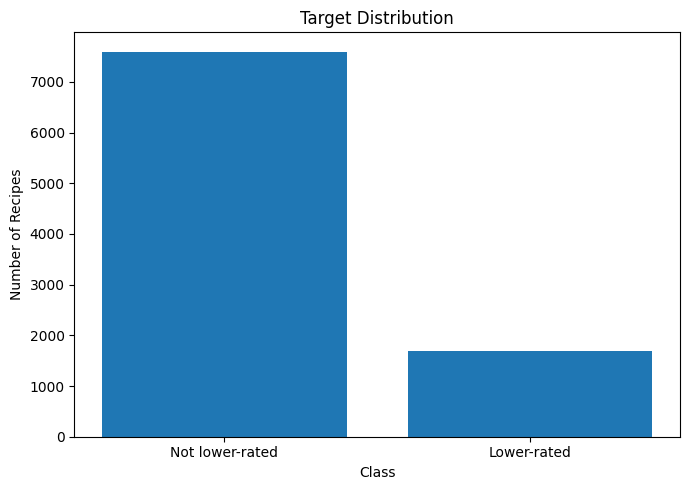

In [42]:
target_counts = recipes["is_lower_rated"].value_counts().sort_index()
labels = ["Not lower-rated", "Lower-rated"]

plt.figure(figsize=(7, 5))
plt.bar(labels, target_counts.values)
plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Recipes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Create Ingredient Indicator Features

Ingredient indicators are binary features showing whether a recipe contains a specific ingredient.

To keep the model manageable, the notebook uses the top 100 most common ingredients.

In [43]:
long_filtered = long_df[
    long_df["recipe_id"].isin(recipes["recipe_id"])
].copy()

long_filtered = long_filtered.dropna(subset=["ingredient_canonical"])

top_ingredients = (
    long_filtered["ingredient_canonical"]
    .value_counts()
    .head(TOP_N_INGREDIENTS)
    .index
)

long_top = long_filtered[
    long_filtered["ingredient_canonical"].isin(top_ingredients)
].copy()

ingredient_matrix = pd.crosstab(
    long_top["recipe_id"],
    long_top["ingredient_canonical"]
).reset_index()

ingredient_matrix.columns = [
    "recipe_id" if col == "recipe_id" else f"ing_{col}"
    for col in ingredient_matrix.columns
]

print("Ingredient matrix shape:", ingredient_matrix.shape)
ingredient_matrix.head()

Ingredient matrix shape: (8983, 101)


,recipe_id,ing_8 ounce package cream cheese,ing_all-purpose flour,ing_allspice,ing_bacon,ing_baking powder,ing_baking soda,ing_bay leaf,ing_beef,ing_black pepper,ing_brown sugar,ing_butter,ing_buttermilk,ing_canola oil,ing_carrot,ing_cayenne pepper,ing_celery,ing_cheddar cheese,ing_chicken broth,ing_chili powder,ing_cilantro,ing_cinnamon,ing_clove,ing_cold water,ing_confectioners' sugar,ing_cooking spray,ing_cornstarch,ing_cumin,ing_dijon mustard,ing_distilled white vinegar,ing_dried basil,ing_dried oregano,ing_dried parsley,ing_dried thyme,ing_egg,ing_egg white,ing_egg yolk,ing_extra-virgin olive oil,ing_freshly black pepper,ing_garlic,ing_garlic powder,ing_ginger,ing_green bell pepper,ing_green onion,ing_heavy cream,ing_heavy whipping cream,ing_honey,ing_italian seasoning,ing_ketchup,ing_kosher salt,ing_large egg,ing_large onion,ing_lean beef,ing_lemon juice,ing_lemon zest,ing_lime juice,ing_margarine,ing_mayonnaise,ing_medium onion,ing_milk,ing_mozzarella cheese,ing_mushroom,ing_nutmeg,ing_olive oil,ing_onion,ing_onion powder,ing_orange juice,ing_packed brown sugar,ing_paprika,ing_parmesan cheese,ing_parsley,ing_pecan,ing_pepper,ing_raisin,ing_red bell pepper,ing_red onion,ing_red pepper flake,ing_rolled oat,ing_salt,ing_salt and black pepper,ing_salt and freshly black pepper,ing_salt and pepper,ing_semisweet chocolate chip,ing_sesame oil,ing_shortening,ing_small onion,ing_sour cream,ing_soy sauce,ing_stalks celery,ing_sugar,ing_tomato,ing_tomato paste,ing_unsalted butter,ing_unsweetened cocoa powder,ing_vanilla extract,ing_vegetable oil,ing_walnut,ing_water,ing_white sugar,ing_whole wheat flour,ing_worcestershire sauce
0,24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,44,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,57,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,63,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,82,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 8. Visualize the Most Common Ingredients

This graph shows the most common ingredients used as indicator variables.

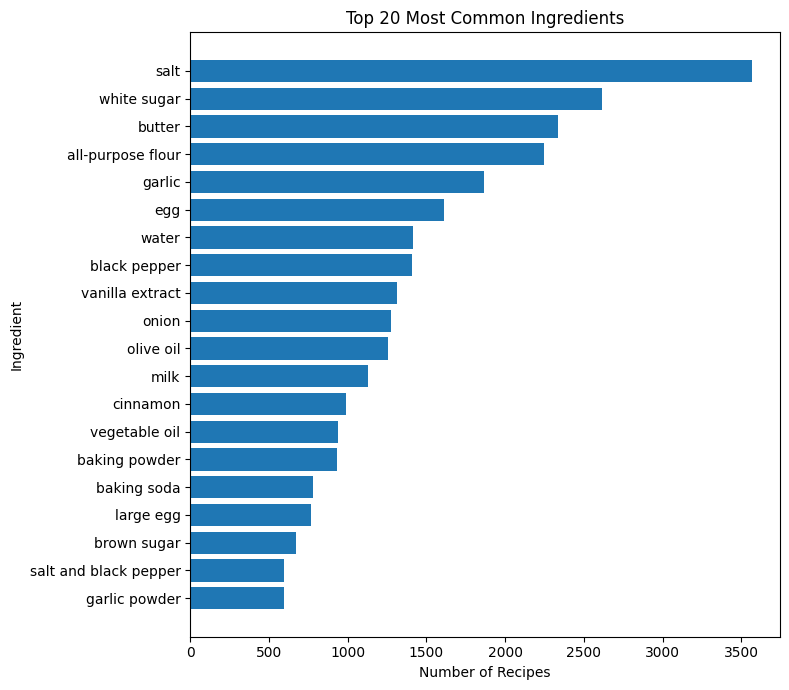

In [44]:
top_20_ingredients = (
    long_filtered["ingredient_canonical"]
    .value_counts()
    .head(20)
    .sort_values()
)

plt.figure(figsize=(8, 7))
plt.barh(top_20_ingredients.index, top_20_ingredients.values)
plt.title("Top 20 Most Common Ingredients")
plt.xlabel("Number of Recipes")
plt.ylabel("Ingredient")
plt.tight_layout()
plt.show()

## 9. Build the Modeling Dataset

This combines recipe-level features with ingredient indicator features.

In [45]:
model_df = recipes.merge(ingredient_matrix, on="recipe_id", how="left")

ingredient_features = [
    col for col in model_df.columns
    if col.startswith("ing_")
]

model_df[ingredient_features] = model_df[ingredient_features].fillna(0)

nutrition_features = [
    "nutrition_calories_num",
    "nutrition_carbs_num",
    "nutrition_fat_num",
    "nutrition_protein_num"
]

recipe_level_features = [
    "ingredient_count",
    "rating_count_num",
    "log_rating_count"
]

full_features = nutrition_features + recipe_level_features + ingredient_features

model_df = model_df.dropna(subset=full_features + ["is_lower_rated"]).copy()

print("Final modeling dataset shape:", model_df.shape)
print("Number of full features:", len(full_features))
print("Number of ingredient features:", len(ingredient_features))

model_df.head()

Final modeling dataset shape: (9009, 118)
Number of full features: 107
Number of ingredient features: 100


,recipe_id,title,rating_value,rating_value_num,rating_count,rating_count_num,nutrition_calories,nutrition_calories_num,nutrition_carbs,nutrition_carbs_num,nutrition_fat,nutrition_fat_num,nutrition_protein,nutrition_protein_num,url,ingredient_count,is_lower_rated,log_rating_count,ing_8 ounce package cream cheese,ing_all-purpose flour,ing_allspice,ing_bacon,ing_baking powder,ing_baking soda,ing_bay leaf,ing_beef,ing_black pepper,ing_brown sugar,ing_butter,ing_buttermilk,ing_canola oil,ing_carrot,ing_cayenne pepper,ing_celery,ing_cheddar cheese,ing_chicken broth,ing_chili powder,ing_cilantro,ing_cinnamon,ing_clove,ing_cold water,ing_confectioners' sugar,ing_cooking spray,ing_cornstarch,ing_cumin,ing_dijon mustard,ing_distilled white vinegar,ing_dried basil,ing_dried oregano,ing_dried parsley,ing_dried thyme,ing_egg,ing_egg white,ing_egg yolk,ing_extra-virgin olive oil,ing_freshly black pepper,ing_garlic,ing_garlic powder,ing_ginger,ing_green bell pepper,ing_green onion,ing_heavy cream,ing_heavy whipping cream,ing_honey,ing_italian seasoning,ing_ketchup,ing_kosher salt,ing_large egg,ing_large onion,ing_lean beef,ing_lemon juice,ing_lemon zest,ing_lime juice,ing_margarine,ing_mayonnaise,ing_medium onion,ing_milk,ing_mozzarella cheese,ing_mushroom,ing_nutmeg,ing_olive oil,ing_onion,ing_onion powder,ing_orange juice,ing_packed brown sugar,ing_paprika,ing_parmesan cheese,ing_parsley,ing_pecan,ing_pepper,ing_raisin,ing_red bell pepper,ing_red onion,ing_red pepper flake,ing_rolled oat,ing_salt,ing_salt and black pepper,ing_salt and freshly black pepper,ing_salt and pepper,ing_semisweet chocolate chip,ing_sesame oil,ing_shortening,ing_small onion,ing_sour cream,ing_soy sauce,ing_stalks celery,ing_sugar,ing_tomato,ing_tomato paste,ing_unsalted butter,ing_unsweetened cocoa powder,ing_vanilla extract,ing_vegetable oil,ing_walnut,ing_water,ing_white sugar,ing_whole wheat flour,ing_worcestershire sauce
0,24,Air Fryer Honey-Mustard Chicken Thighs,4.7,4.7,15.0,15.0,364 kcal,364.0,10 g,10.0,20 g,20.0,38 g,38.0,https://www.allrecipes.com/air-fryer-honey-mus...,9,0,2.772589,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,44,Air Fryer Smashed Potatoes,4.8,4.8,16.0,16.0,158 kcal,158.0,24 g,24.0,6 g,6.0,3 g,3.0,https://www.allrecipes.com/air-fryer-smashed-p...,6,0,2.833213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,57,Lemon Garlic Butter Chicken Spiedini,4.9,4.9,81.0,81.0,637 kcal,637.0,22 g,22.0,41 g,41.0,43 g,43.0,https://www.allrecipes.com/lemon-garlic-butter...,18,0,4.406719,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,63,Best Egg Salad,4.7,4.7,10.0,10.0,334 kcal,334.0,4 g,4.0,27 g,27.0,17 g,17.0,https://www.allrecipes.com/best-egg-salad-reci...,10,0,2.397895,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.

## 10. Train-Test Split

The same train-test split is used for all models so the comparison is fair.

In [46]:
train_df, test_df = train_test_split(
    model_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=model_df["is_lower_rated"]
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain target distribution:")
print(train_df["is_lower_rated"].value_counts(normalize=True).round(4))

print("\nTest target distribution:")
print(test_df["is_lower_rated"].value_counts(normalize=True).round(4))

Train shape: (6756, 118)
Test shape: (2253, 118)

Train target distribution:
is_lower_rated
0    0.8175
1    0.1825
Name: proportion, dtype: float64

Test target distribution:
is_lower_rated
0    0.8176
1    0.1824
Name: proportion, dtype: float64


## 11. Evaluation Function

The evaluation function trains a model and returns accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrix values.

In [47]:
def evaluate_model(model_name, model, feature_cols, train_df, test_df, threshold=0.50):
    X_train = train_df[feature_cols]
    y_train = train_df["is_lower_rated"]

    X_test = test_df[feature_cols]
    y_test = test_df["is_lower_rated"]

    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        y_prob = None
        y_pred = model.predict(X_test)
        roc_auc = np.nan

    cm = confusion_matrix(y_test, y_pred)

    result = {
        "model": model_name,
        "threshold": threshold,
        "num_features": len(feature_cols),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc,
        "true_negative": cm[0, 0],
        "false_positive": cm[0, 1],
        "false_negative": cm[1, 0],
        "true_positive": cm[1, 1],
    }

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    return result, model, y_pred, y_prob, report

## 12. Champion and Challenger Models

The champion model is Logistic Regression with full features.

This is the champion because it provides the strongest balance between interpretability and lower-rated recipe detection. It uses all available modeling features and gives coefficients that can be interpreted.

The challenger models are used to test whether simpler or different approaches perform better.

In [48]:
models = [
    (
        "Champion: Logistic Regression, full features",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ))
        ]),
        full_features
    ),
    (
        "Challenger 1: Logistic Regression, nutrition only",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ))
        ]),
        nutrition_features
    ),
    (
        "Challenger 2: Random Forest, full features",
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            max_depth=None,
            n_jobs=-1
        ),
        full_features
    ),
    (
        "Challenger 3: Random Forest, ingredients only",
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            max_depth=None,
            n_jobs=-1
        ),
        ingredient_features
    ),
]

## 13. Train and Compare Champion and Challenger Models

This section trains the champion and challenger models and compares their results.

In [49]:
results = []
trained_models = {}
reports = {}
predictions = {}
probabilities = {}
feature_sets = {}

for model_name, model, feature_cols in models:
    print("Running:", model_name)

    result, fitted_model, y_pred, y_prob, report = evaluate_model(
        model_name=model_name,
        model=model,
        feature_cols=feature_cols,
        train_df=train_df,
        test_df=test_df
    )

    results.append(result)
    trained_models[model_name] = fitted_model
    reports[model_name] = report
    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob
    feature_sets[model_name] = feature_cols

results_df = pd.DataFrame(results).sort_values(
    ["f1", "roc_auc"],
    ascending=False
).reset_index(drop=True)

results_df

Running: Champion: Logistic Regression, full features
Running: Challenger 1: Logistic Regression, nutrition only
Running: Challenger 2: Random Forest, full features
Running: Challenger 3: Random Forest, ingredients only


,model,threshold,num_features,accuracy,precision,recall,f1,roc_auc,true_negative,false_positive,false_negative,true_positive
0,"Champion: Logistic Regression, full features",0.5,107,0.607190,0.273423,0.695864,0.392588,0.697487,1082,760,125,286
1,"Challenger 1: Logistic Regression, nutrition only",0.5,4,0.501997,0.211679,0.635036,0.317518,0.568568,870,972,150,261
2,"Challenger 3: Random Forest, ingredients only",0.5,100,0.777630,0.252747,0.111922,0.155143,0.597631,1706,136,365,46
3,"Challenger 2: Random Forest, full features",0.5,107,0.818464,0.562500,0.021898,0.042155,0.702927,1835,7,402,9


## 14. Add SMOTE Logistic Regression

SMOTE is tested because the lower-rated class is smaller than the not-lower-rated class.

SMOTE creates synthetic examples of the minority class in the training data. This can help the model learn the lower-rated class better.

In [50]:
if SMOTE_AVAILABLE:
    smote_logistic = ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            random_state=RANDOM_STATE
        ))
    ])

    smote_result, smote_model, smote_pred, smote_prob, smote_report = evaluate_model(
        model_name="Additional Test: SMOTE Logistic Regression, full features",
        model=smote_logistic,
        feature_cols=full_features,
        train_df=train_df,
        test_df=test_df
    )

    results_df = pd.concat(
        [results_df, pd.DataFrame([smote_result])],
        ignore_index=True
    ).sort_values(["f1", "roc_auc"], ascending=False).reset_index(drop=True)

    trained_models[smote_result["model"]] = smote_model
    reports[smote_result["model"]] = smote_report
    predictions[smote_result["model"]] = smote_pred
    probabilities[smote_result["model"]] = smote_prob
    feature_sets[smote_result["model"]] = full_features

else:
    print("SMOTE is not available. Install it with: python3 -m pip install imbalanced-learn")

results_df

,model,threshold,num_features,accuracy,precision,recall,f1,roc_auc,true_negative,false_positive,false_negative,true_positive
0,"Additional Test: SMOTE Logistic Regression, fu...",0.5,107,0.623169,0.278340,0.669100,0.393138,0.695125,1129,713,136,275
1,"Champion: Logistic Regression, full features",0.5,107,0.607190,0.273423,0.695864,0.392588,0.697487,1082,760,125,286
2,"Challenger 1: Logistic Regression, nutrition only",0.5,4,0.501997,0.211679,0.635036,0.317518,0.568568,870,972,150,261
3,"Challenger 3: Random Forest, ingredients only",0.5,100,0.777630,0.252747,0.111922,0.155143,0.597631,1706,136,365,46
4,"Challenger 2: Random Forest, full features",0.5,107,0.818464,0.562500,0.021898,0.042155,0.702927,1835,7,402,9


## 15. Model Comparison Visuals


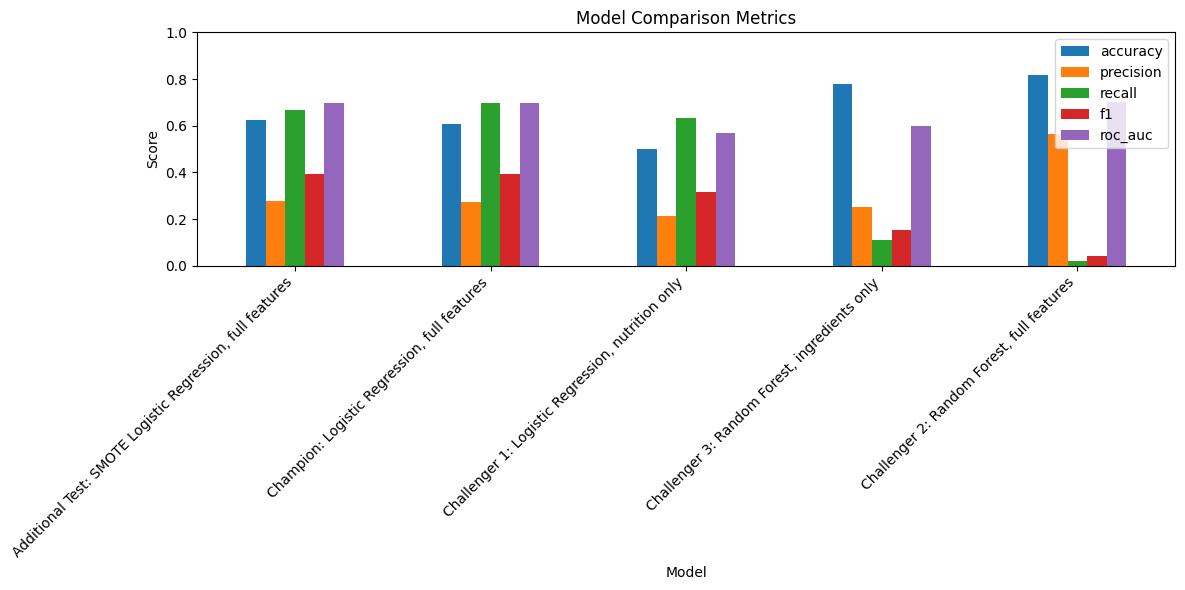

In [51]:
plot_df = results_df.set_index("model")[["accuracy", "precision", "recall", "f1", "roc_auc"]]

plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Model Comparison Metrics")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

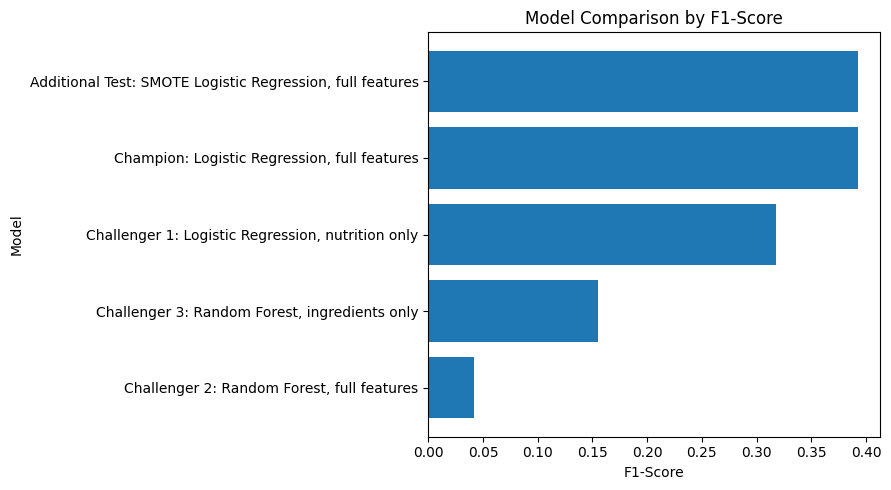

In [52]:
f1_sorted = results_df.sort_values("f1")

plt.figure(figsize=(9, 5))
plt.barh(f1_sorted["model"], f1_sorted["f1"])
plt.title("Model Comparison by F1-Score")
plt.xlabel("F1-Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

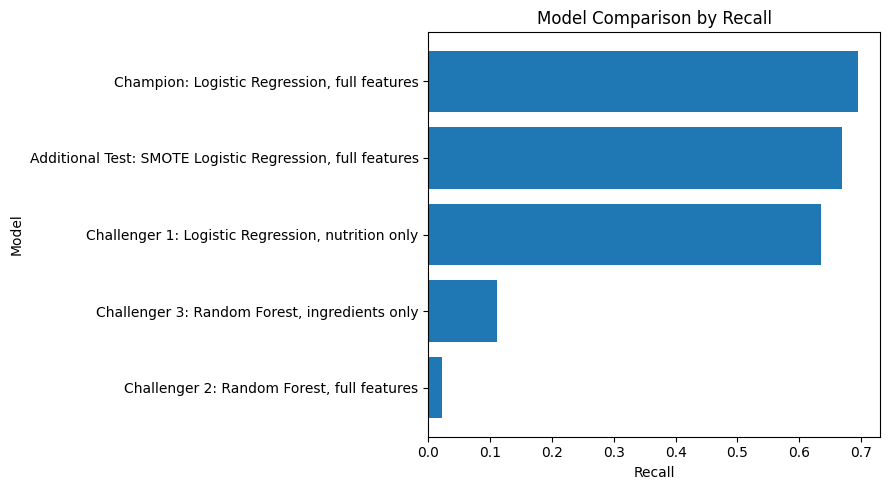

In [53]:
recall_sorted = results_df.sort_values("recall")

plt.figure(figsize=(9, 5))
plt.barh(recall_sorted["model"], recall_sorted["recall"])
plt.title("Model Comparison by Recall")
plt.xlabel("Recall")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## 16. Confusion Matrix Visuals

The confusion matrix shows how many recipes were classified correctly and incorrectly.

For this project, false negatives are important because they are lower-rated recipes that the model missed.

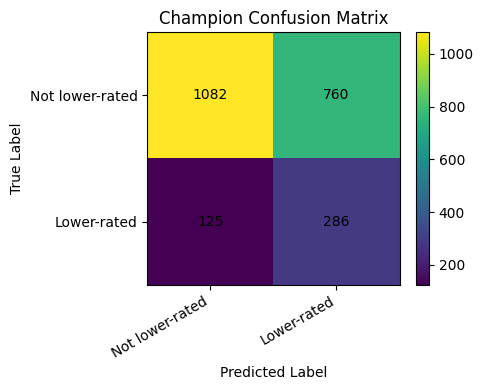

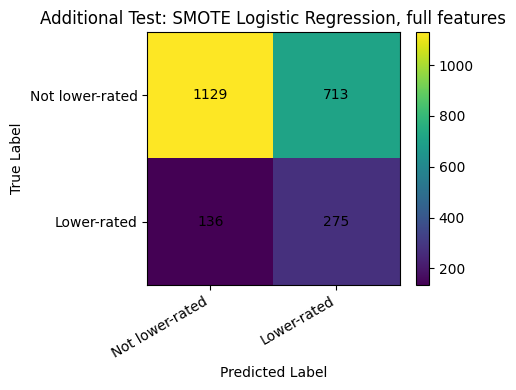

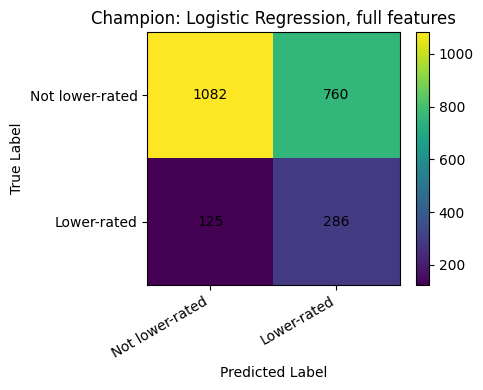

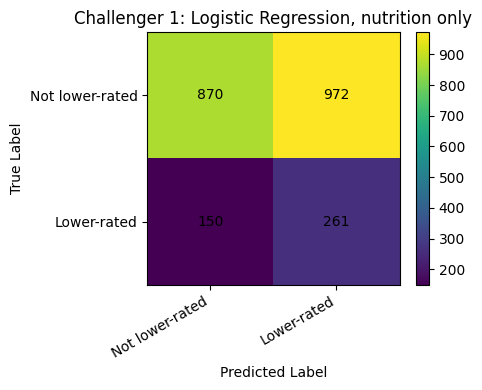

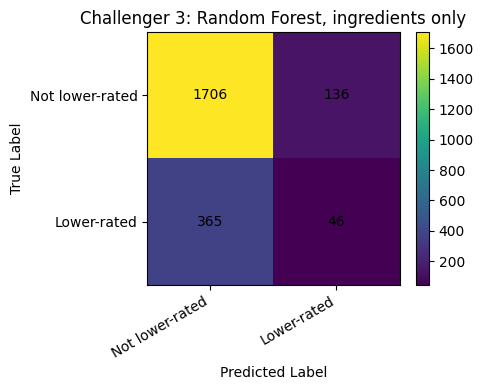

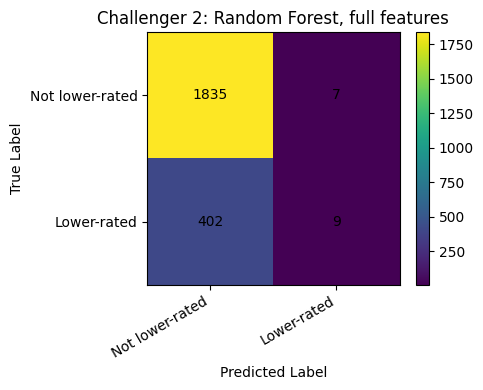

In [54]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks([0, 1], ["Not lower-rated", "Lower-rated"], rotation=30, ha="right")
    plt.yticks([0, 1], ["Not lower-rated", "Lower-rated"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()


champion_name = "Champion: Logistic Regression, full features"
y_test = test_df["is_lower_rated"]

champion_cm = confusion_matrix(y_test, predictions[champion_name])
plot_confusion_matrix(champion_cm, "Champion Confusion Matrix")

for model_name in results_df["model"]:
    cm = confusion_matrix(y_test, predictions[model_name])
    plot_confusion_matrix(cm, model_name)

## 17. ROC Curves

ROC curves compare how well the models separate lower-rated recipes from not-lower-rated recipes across probability thresholds.

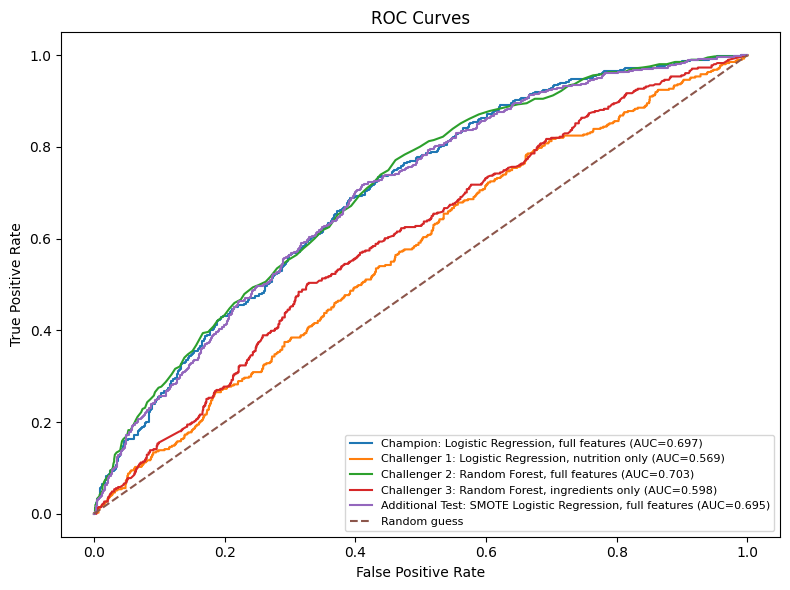

In [55]:
plt.figure(figsize=(8, 6))

for model_name, y_prob in probabilities.items():
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_value = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random guess")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 18. Precision-Recall Curves

Precision-recall curves are useful when the target class is imbalanced.

These curves focus more directly on how well the model identifies the lower-rated class.

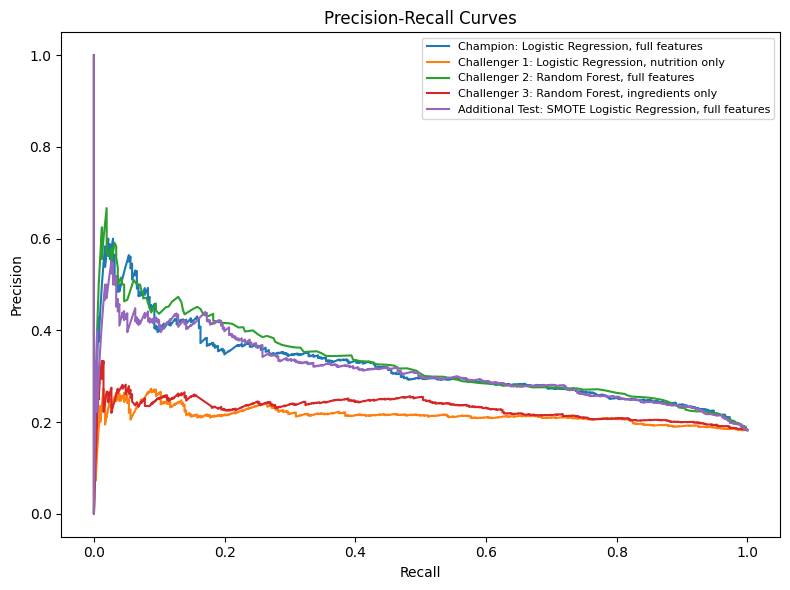

In [56]:
plt.figure(figsize=(8, 6))

for model_name, y_prob in probabilities.items():
    if y_prob is not None:
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        plt.plot(recall, precision, label=model_name)

plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 19. Logistic Regression Coefficients

The champion model is Logistic Regression with full features.

Positive coefficients are associated with a higher chance of being lower-rated. Negative coefficients are associated with a lower chance of being lower-rated.

In [57]:
champion_model = trained_models[champion_name]
champion_features = feature_sets[champion_name]

logistic_inner_model = champion_model.named_steps["model"]

coefficients = pd.DataFrame({
    "feature": champion_features,
    "coefficient": logistic_inner_model.coef_[0]
})

coefficients["absolute_coefficient"] = coefficients["coefficient"].abs()

coefficients = coefficients.sort_values(
    "absolute_coefficient",
    ascending=False
).reset_index(drop=True)

coefficients.head(25)

,feature,coefficient,absolute_coefficient
0,log_rating_count,-0.589591,0.589591
1,ingredient_count,-0.517759,0.517759
2,rating_count_num,-0.374390,0.374390
3,nutrition_protein_num,0.270488,0.270488
4,nutrition_carbs_num,0.258803,0.258803
5,nutrition_calories_num,-0.254221,0.254221
6,ing_salt and pepper,0.188887,0.188887
7,ing_extra-virgin olive oil,-0.179346,0.179346
8,ing_kosher salt,-0.175419,0.175419
9,ing_water,0.156923,0.156923


## 20. Coefficient Visuals

These graphs show the strongest positive and negative coefficients from the champion model.

Positive coefficients are associated with lower-rated recipes. Negative coefficients are associated with not being lower-rated.

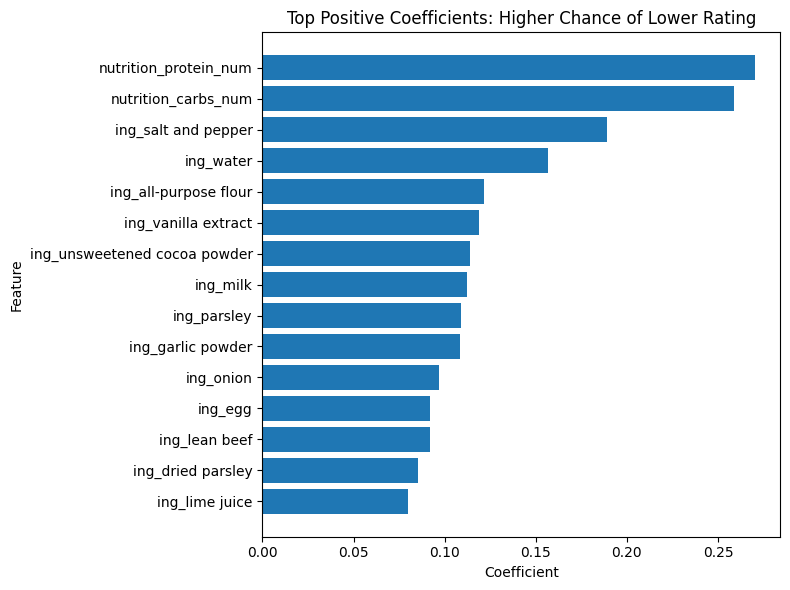

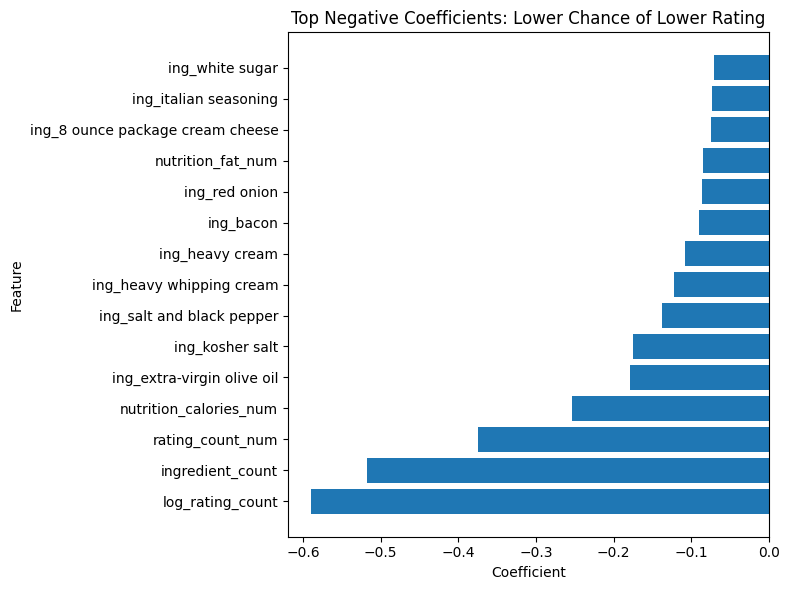

In [58]:
top_positive = coefficients.sort_values("coefficient", ascending=False).head(15).sort_values("coefficient")
top_negative = coefficients.sort_values("coefficient", ascending=True).head(15).sort_values("coefficient")

plt.figure(figsize=(8, 6))
plt.barh(top_positive["feature"], top_positive["coefficient"])
plt.title("Top Positive Coefficients: Higher Chance of Lower Rating")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.barh(top_negative["feature"], top_negative["coefficient"])
plt.title("Top Negative Coefficients: Lower Chance of Lower Rating")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 21. Random Forest Feature Importance

This section is for comparison only. The Random Forest challenger provides feature importance values, but the Logistic Regression model remains the champion because it gives better lower-rated detection and clearer interpretation.

,feature,importance
0,rating_count_num,0.104501
1,log_rating_count,0.102670
2,nutrition_calories_num,0.082491
3,nutrition_carbs_num,0.077382
4,nutrition_fat_num,0.072041
5,nutrition_protein_num,0.068147
6,ingredient_count,0.062248
7,ing_salt,0.013336
8,ing_butter,0.012750
9,ing_white sugar,0.011858


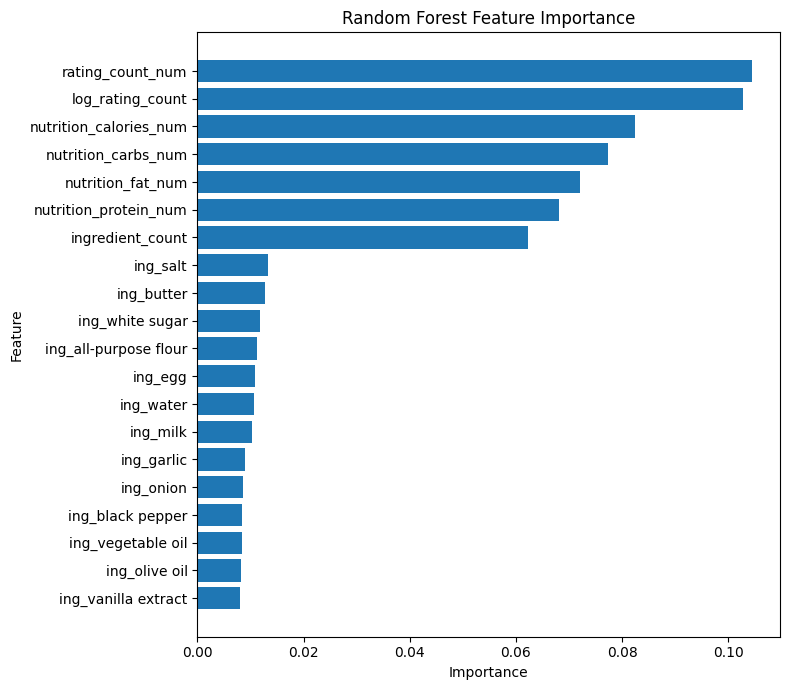

In [59]:
rf_name = "Challenger 2: Random Forest, full features"

if rf_name in trained_models:
    rf_model = trained_models[rf_name]
    rf_features = feature_sets[rf_name]

    rf_importance = pd.DataFrame({
        "feature": rf_features,
        "importance": rf_model.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    display(rf_importance.head(25))

    top_rf = rf_importance.head(20).sort_values("importance")

    plt.figure(figsize=(8, 7))
    plt.barh(top_rf["feature"], top_rf["importance"])
    plt.title("Random Forest Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

## 22. Save Outputs

These files are saved for use in the final report.

In [61]:
results_df.to_csv("model_comparison_results.csv", index=False)

confusion_df = results_df[
    [
        "model",
        "threshold",
        "true_negative",
        "false_positive",
        "false_negative",
        "true_positive"
    ]
].copy()

confusion_df.to_csv("confusion_matrices.csv", index=False)

coefficients.to_csv("champion_logistic_coefficients.csv", index=False)

champion_report = pd.DataFrame(reports[champion_name]).transpose()
champion_report.to_csv("classification_report_champion.csv")

if "rf_importance" in globals():
    rf_importance.to_csv("random_forest_feature_importance.csv", index=False)

print("Saved outputs:")
print("- model_comparison_results.csv")
print("- confusion_matrices.csv")
print("- champion_logistic_coefficients.csv")
print("- classification_report_champion.csv")
print("- random_forest_feature_importance.csv")

Saved outputs:
- model_comparison_results.csv
- confusion_matrices.csv
- champion_logistic_coefficients.csv
- classification_report_champion.csv
- random_forest_feature_importance.csv
